<a href="https://colab.research.google.com/github/nicolastibata/MINE_4210_ADL_202620/blob/main/labs/Laboratorio_6/MINE_4210_ADL_202620_L6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![Logo ADL](https://github.com/nicolastibata/MINE_4210_ADL_202620/blob/main/docs/logo.png?raw=true)


# **Laboratorio 6: Modelo LSTM + Despliegue**
**Tutor: Nicolás Tibatá**

## **Tabla de Contenido**

[Contexto y objetivos](#scrollTo=R4YrUaE6udsU&line=14&uniqifier=1)<br>
[1. Comprensión de los datos](#scrollTo=VjA8zwzJvmeO&line=1&uniqifier=1)<br>
[2. Preparación de los datos](#scrollTo=kG8XHROzvuEH&line=1&uniqifier=1)<br>
[3. Modelamiento](#scrollTo=wCS6xYiU4YYs&line=1&uniqifier=1)<br>
[4. Evaluación](#scrollTo=nnCc67Uf5urd&line=1&uniqifier=1)<br>
[5. Despliegue](#scrollTo=WTSOjYFHxoOJ&line=1&uniqifier=1)<br>

### **Contexto y Objetivos**

**Problema**
- La alineación de textos, propuestas de proyectos y normativas con los Objetivos de Desarrollo Sostenible (ODS) de la ONU es clave para medir el impacto social y ambiental, pero clasificarlos suele ser un proceso muy manual y costoso. Al querer capturar las relaciones semánticas del texto se propone construir un pipeline de Procesamiento de Lenguaje Natural (NLP) basado en capas de Embedding y redes LSTM, donde se pueda ver en una aplicación que automatice la clasificación individual y masiva de textos.

**Objetivos**
1. Desarrollar un modelo basado en capas de Embedding y redes recurrentes LSTM para la clasificación automática de textos.
2. Implementar el procesamiento de texto utilizando tokenización, padding de secuencias y una capa de Embedding entrenable para representar vectorialmente las relaciones semánticas entre palabras.


**Datos**

Los datos los puedes consultar [aquí](https://github.com/nicolastibata/MINE_4210_ADL_202620/blob/main/labs/Laboratorio_6).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

### **1. Comprensión de los datos**

In [2]:
# Leemos el .xlsx de github
url = 'https://github.com/nicolastibata/MINE_4210_ADL_202620/blob/main/labs/Laboratorio_6/TextosODS.xlsx?raw=true'
df = pd.read_excel(url)
print(df.head())

                                              textos  ODS
0  "Aprendizaje" y "educación" se consideran sinó...    4
1  No dejar clara la naturaleza de estos riesgos ...    6
2  Como resultado, un mayor y mejorado acceso al ...   13
3  Con el Congreso firmemente en control de la ju...   16
4  Luego, dos secciones finales analizan las impl...    5


**Agreguemos los nombres de los diferentes IDs de nuestros textos ODS, la info la encontramos acá: https://www.un.org/sustainabledevelopment/es/sustainable-development-goals/**

In [3]:
# Agreguemos los nombres de los diferentes IDs ODS
ods_names = {
    1: 'Fin de la pobreza',
    2: 'Hambre cero',
    3: 'Salud y Bienestar',
    4: 'Educación de Calidad',
    5: 'Igualdad de Género',
    6: 'Agua limpia y Saneamiento',
    7: 'Energía asequible y no contaminante',
    8: 'Trabajo decente y crecimiento económico',
    9: 'Industria, Innovación e Infraestructura',
    10: 'Reducción de las desigualdades',
    11: 'Ciudades y comunidades sostenibles',
    12: 'Producción y consumo responsable',
    13: 'Acción por el clima',
    14: 'Vida submarina',
    15: 'Vida de ecosistemas terrestres',
    16: 'Paz, Justicia e Instituciones Sólidas'
}

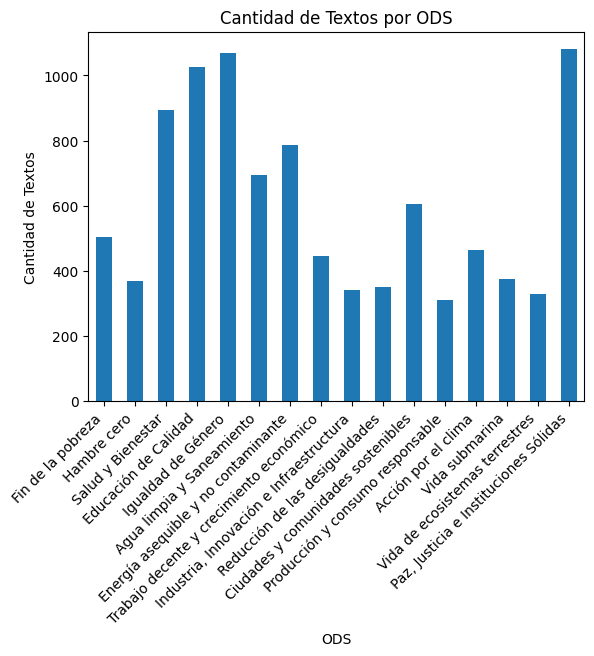

In [4]:
# Contamos los valores y los ordenamos por el ID del ODS
counts = df['ODS'].value_counts().sort_index()

# Graficamos
counts.plot(kind='bar')
plt.title('Cantidad de Textos por ODS')
plt.xlabel('ODS')
plt.ylabel('Cantidad de Textos')
plt.xticks(range(len(counts)), [ods_names[i] for i in counts.index], rotation=45, ha='right')
plt.show();

In [5]:
# Contemos la cantidad de textos por cada ODS
df['ODS'].value_counts()

,count
ODS,
16,1080
5,1070
4,1025
3,894
7,787
6,695
11,607
1,505
13,464


### **2. Preparación de los datos**

Debemos usar un `LabelEncoder()` para poder asignar correctamente nuestros IDs de ODS con nuestras neuronas de salida

In [6]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['ODS'])
num_classes = len(np.unique(y))
print(y)
print(num_classes)

[ 3  5 12 ...  8  5  3]
16


Definimos nuestros máximos de número de palabras y longitud de secuencia

In [7]:
MAX_WORDS = 10000
MAX_SEQUENCE_LENGTH = 50

En modelos LSTM no es necesario que apliquemos Stemming ni Lemmatization en la mayoría de los casos. A diferencia de los modelos tradicionales (Naive Bayes o SVM con TF-IDF), las redes LSTM se benefician de mantener el contexto y la sintaxis original.

Pero si debemos hacer una limpieza básica como lo es pasar de mayúsculas a minúsculas o puntuación. La clase `Tokenizer()` nos ayuda a realizar esos procesos automáticamente.

> OOV: Hace referencia a 'Out of Vocabulary'. Al tener `MAX_WORDS = 10000` estamos guardando las 10000 palabras más frecuentes. Cuando el modelo recibe una palabra por fuera de estas 10000 como lo es un nombre específico entonces no la elimina sino usa el token `OOV` para mantener el contexto.

In [8]:
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(df['textos'])

sequences = tokenizer.texts_to_sequences(df['textos'])
X = pad_sequences(sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

Definimos nuestra dimension de los vectores de embedding

In [9]:
EMBEDDING_DIM = 64

Realizamos el split de nuestros datos

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=71, stratify=y
)

### **3. Modelamiento**

**Antes de empezar a modelar veamos la arquitectura LSTM y lo que es un Embedding:**

- La arquitectura LSTM nos ayuda mucho a nuestro problema. Pues no queremos perder el contexto de nuestros textos (si son muy largos) pero tampoco ignorar el contexto de las distancias cortas de nuestros textos.  


Entonces qué es y por qué necesitamos el embedding?

- Los embeddings son espacios altamente dimensionales de vectores. Basicamente convierte el texto a números (que eso también lo hace un tokenizador) pero teniendo en cuenta la relación **semántica** de las palabras, para que el modelo pueda entender las relaciones que hay y realizar comparaciones.



Teniendo esto claro, lo que hacemos es convertir nuestras palabras a números con el tokenizador, luego creamos un espacio vectorial para guardar las relaciones o la semántica de las palabras, y este espacio vectorial se lo brindamos al modelo LSTM.

In [11]:
# Revisamos que tenemos la GPU activa
gpus = tf.config.list_physical_devices('GPU')
print("GPUs detectadas:", gpus)

GPUs detectadas: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [48]:
model = tf.keras.Sequential([
    # Capa 1: Embedding
    tf.keras.layers.Embedding(
        input_dim=MAX_WORDS,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_SEQUENCE_LENGTH,
        mask_zero=True),
        # mask_zero = True nos indica que el padding no se tome como texto adicional
    # Capa 2: LSTM
    tf.keras.layers.SpatialDropout1D(0.5),
    tf.keras.layers.LSTM(64, dropout=0.5),
    # Capa 3: Capa Densa de Clasificación
    tf.keras.layers.Dense(
        num_classes,
        activation='softmax',
        kernel_regularizer=tf.keras.regularizers.l2(0.001))
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [49]:
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()
# Por qué nos sale sin la cantidad de parámetros?

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_7             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [50]:
pesos = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(pesos))

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weight_dict,
    callbacks=[early_stop]
)

Epoch 1/30
242/242 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.1378 - loss: 2.7109 - val_accuracy: 0.3204 - val_loss: 2.2036
Epoch 2/30
242/242 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.3020 - loss: 2.2265 - val_accuracy: 0.3861 - val_loss: 1.8864
Epoch 3/30
242/242 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.3902 - loss: 1.9672 - val_accuracy: 0.4591 - val_loss: 1.6635
Epoch 4/30
242/242 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.4441 - loss: 1.7576 - val_accuracy: 0.5352 - val_loss: 1.5101
Epoch 5/30
242/242 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5016 - loss: 1.5868 - val_accuracy: 0.5280 - val_loss: 1.4908
Epoch 6/30
242/242 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5311 - loss: 1.4760 - val_accuracy: 0.5626 - val_loss: 1.4018
Epoch 7/30
242/242 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5809 - loss: 1.3640 - val_accuracy: 0.5797 - val_loss: 1.3534
Epoch 8/30
242/242 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6073 - loss: 1.2924 - val_accurac

**Veamos los resultados de nuestro modelo con los datos de entrenamiento**

In [52]:
ods_labels = [str(cls) for cls in label_encoder.classes_]
y_pred = np.argmax(model.predict(X_train), axis=1)
print(classification_report(y_train, y_pred, target_names=ods_labels))

242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

           1       0.94      0.93      0.93       404
           2       0.93      0.93      0.93       295
           3       0.99      0.95      0.97       715
           4       0.96      0.98      0.97       820
           5       0.95      0.94      0.95       856
           6       0.94      0.90      0.92       556
           7       0.97      0.88      0.92       629
           8       0.85      0.90      0.87       357
           9       0.81      0.93      0.86       274
          10       0.87      0.89      0.88       282
          11       0.95      0.94      0.94       485
          12       0.91      0.99      0.95       250
          13       0.98      0.95      0.96       371
          14       0.94      0.83      0.88       302
          15       0.75      0.97      0.85       264
          16       0.99      0.98      0.98       864

    accuracy                           

### **4. Evaluación**

In [53]:
y_pred_test = np.argmax(model.predict(X_test), axis=1)

61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step



--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           1       0.62      0.64      0.63       101
           2       0.51      0.61      0.55        74
           3       0.87      0.80      0.83       179
           4       0.81      0.90      0.85       205
           5       0.86      0.84      0.85       214
           6       0.86      0.82      0.84       139
           7       0.86      0.66      0.75       158
           8       0.40      0.47      0.44        89
           9       0.46      0.54      0.50        69
          10       0.42      0.37      0.39        70
          11       0.64      0.65      0.64       122
          12       0.54      0.60      0.56        62
          13       0.77      0.68      0.72        93
          14       0.75      0.63      0.68        75
          15       0.64      0.83      0.72        66
          16       0.89      0.88      0.89       216

    accuracy                           0.73   

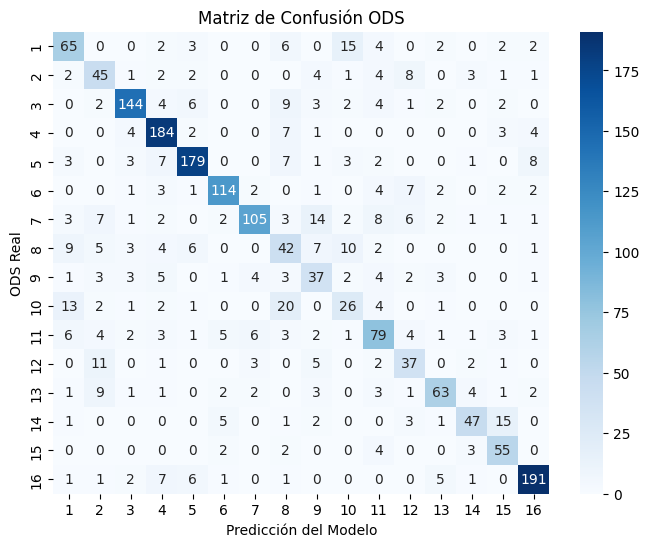

In [54]:
# Veamos en test
ods_labels = [str(cls) for cls in label_encoder.classes_]

print("\n--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_test, y_pred_test, target_names=ods_labels))

# Generamos nuestra matriz de confusión
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=ods_labels,
    yticklabels=ods_labels,
)
plt.xlabel("Predicción del Modelo")
plt.ylabel("ODS Real")
plt.title("Matriz de Confusión ODS")
plt.show()

In [55]:
# Por ultimo, guardemos nuestros artefactos para usarlos en el despliegue
model.save("ods_lstm_model.keras")

# Guardamos el tokenizer y el label_encoder
with open("tokenizer.pickle", "wb") as f:
    pickle.dump(tokenizer, f)

with open("label_encoder.pickle", "wb") as f:
    pickle.dump(label_encoder, f)

### **5. Despliegue**

Streamlit es un marco de desarrollo de código abierto, se destaca por su capacidad para facilitar la creación de aplicaciones web interactivas o demos necesarios para poder plasmar nuestras ideas.

Hay muchos frameworks que funcionan, pero usamos este por su facilidad en crear las apps.

Necesitamos 4 cosas :
1. `app.py`
2. `requirements.txt`
3. Artefactos: `model.keras` `tokenizer.pickle` `encoder.pickle` (en nuestro caso)
4. Repo en github

Si queremos testear en local necesitamos un ambiente virtual (venv o conda) para el cual se tienen instaladas las librerias streamlit, tensorflow o las necesarias para el desarrollo.


Link streamlit: https://ods-lstm.streamlit.app/